![ab](ab.png)

### Parse given data

In [86]:
using Distributions
using Plots
using LinearAlgebra
using StatsPlots

q1 = [500, 0]
q2 = [0, 500]
q3 = [500, -200]

q1_unit = q1 / norm(q1)
q2_unit = q2 / norm(q2)
q3_unit = q3 / norm(q3)

A = vcat(q1_unit', q2_unit', q3_unit')
mu_x = [2, 3]
Sx = diagm([1, 1])
Sw = diagm([0.1, 1, 1])

3×3 Matrix{Float64}:
 0.1  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

Simulate x and w distributions

In [87]:
x = MvNormal(mu_x, Sx)

w = MvNormal(zeros(3), Sw)

x_test = rand(x)
w_test = rand(w)

y_sim = A * x_test + w_test

3-element Vector{Float64}:
  1.3913619456860695
  5.353400687964072
 -0.9146688286006573

Calculate MMSE estimate and posterior covariance

In [88]:
Lmmse = A' * inv(A*A' + Sw)
function compute_mmse(y_sim)
    x_mmse = mu_x + Lmmse * (y_sim - A * mu_x)
    return x_mmse
end

x_mmse = compute_mmse(y_sim)

cov_post = I - A' * inv(A*A' + Sw) * A

2×2 Matrix{Float64}:
 0.0846995  0.0136612
 0.0136612  0.469945

Plot

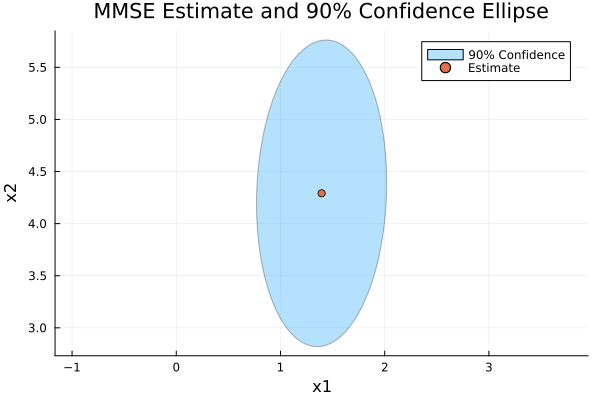

In [104]:
r = sqrt(quantile(Chisq(2), 0.90))

covellipse(x_mmse, cov_post, n_std=r, label="90% Confidence", aspect_ratio=:equal)
scatter!([x_mmse[1]], [x_mmse[2]], label="Estimate")
xlabel!("x1")
ylabel!("x2")
title!("MMSE Estimate and 90% Confidence Ellipse")

### Eigenvalue method of plotting ellipses

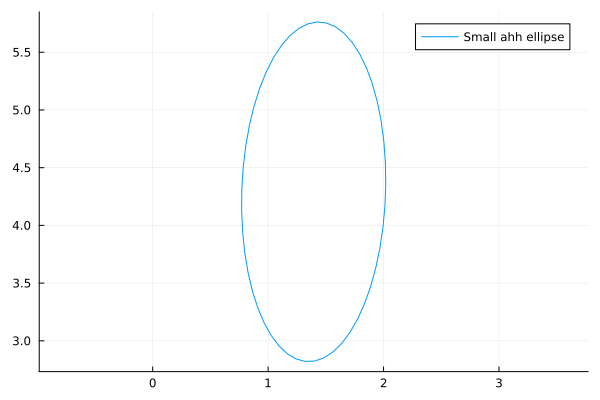

In [90]:
# 1. Eigen decompose
F = eigen(cov_post)
evals = F.values
evecs = F.vectors

# 2. Make unit circle
theta = range(0, 2pi, length=50)
circle = [cos.(theta) sin.(theta)]'

# 3. Calculate the scaling factor, input n dims and confidence level
alpha = quantile(Chisq(2), 0.90)

# 4. Scale by eigvals and rotate by eigenvecs
# The scaling matrix is diagm(sqrt.(alpha .* evals))
ellipse_points = x_mmse .+ evecs * diagm(sqrt.(alpha .* evals)) * circle
plot(ellipse_points[1,:], ellipse_points[2,:], label="Small ahh ellipse", aspect_ratio=:equal)

### Prior Distribution

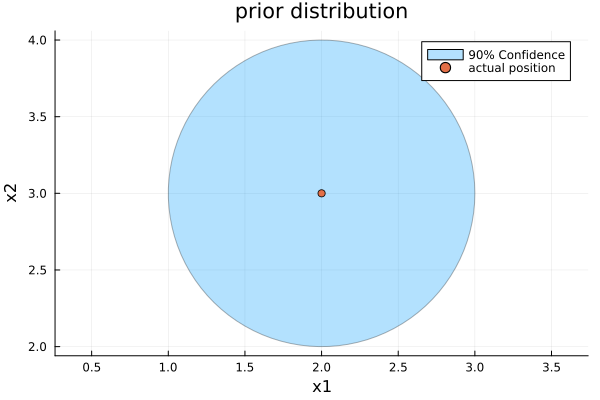

In [ ]:
covellipse(mu_x, Sx, probability=0.90, label="90% Confidence", aspect_ratio=:equal)
scatter!([mu_x[1]], [mu_x[2]], label="actual position")
xlabel!("x1")
ylabel!("x2")
title!("prior distribution")

![c](c.png)

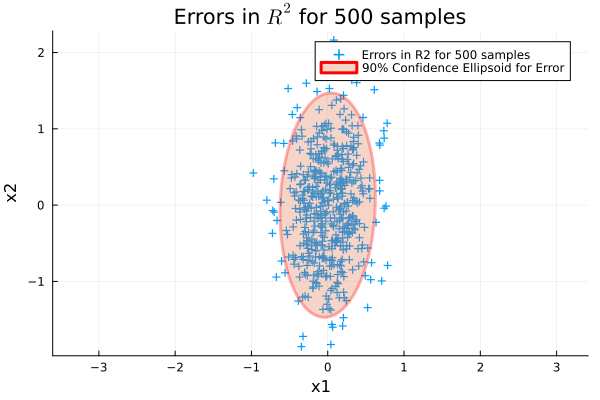

In [107]:
n = 500
x_samples = rand(x, n)
w_samples = rand(w, n)
y_samples = A * x_samples + w_samples

errors = zeros(2, n)
for i in 1:n
    errors[:, i] = x_samples[:, i] - compute_mmse(y_samples[:, i])
end

origin = [0, 0]

Sw_inv = diagm([10, 1, 1])
Serror = inv(I + A' * Sw_inv * A)

scatter(errors[1,:], errors[2,:], label="Errors in R2 for 500 samples", markershape=:cross, markersize=4, markerstrokewidth=1.5)
scatter!(origin[1], origin[2], label="Origin", markershape=:star5, markersize=8, markerstrokewidth=2)
covellipse!(origin, Serror, n_std=r, label="90% Confidence Ellipsoid for Error", aspect_ratio=:equal, linecolor=:red, linewidth=3)
xlabel!("x1")
ylabel!("x2")
title!("Errors in \$R^2\$ for 500 samples")

![d](d.jpeg)

![dAmswer](dAnswer.png)

![e](e.jpeg)

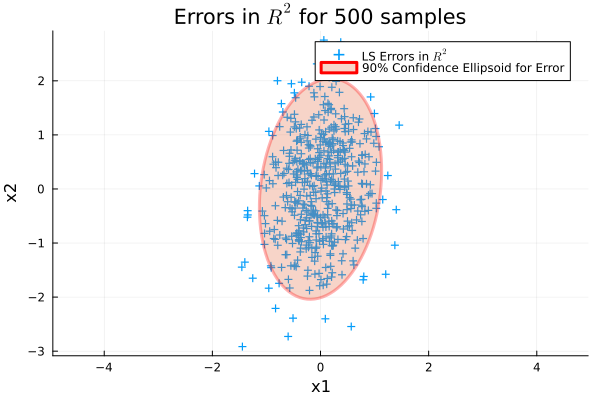

In [110]:
errors_ls = zeros(2, n)
A_dag = pinv(A)

for i in 1:n
    errors_ls[:, i] = - A_dag * (w_samples[:, i])
end

cov_e = A_dag * Sw * A_dag'

scatter(errors_ls[1,:], errors_ls[2,:], label="LS Errors in \$R^2\$", markershape=:cross, markersize=4, markerstrokewidth=1.5)
scatter!(origin[1], origin[2], label="Origin", markershape=:star5, markersize=8, markerstrokewidth=2)
covellipse!(origin, cov_e, n_std=r, label="90% Confidence Ellipsoid for Error", aspect_ratio=:equal, linecolor=:red, linewidth=3)
xlabel!("x1")
ylabel!("x2")
title!("Errors in \$R^2\$ for 500 samples")

![f](f.png)